In [1]:
# ==========================================================
# CELL 1: Environment Setup & Google Drive Mount ('archive' Folder)
# ==========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Set aesthetic visual style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# List of all 7 OULAD CSV files
OULAD_FILES = [
    'assessments.csv', 'courses.csv', 'studentAssessment.csv',
    'studentInfo.csv', 'studentRegistration.csv', 'studentVle.csv', 'vle.csv'
]

# Mount Google Drive and set working directory directly to 'archive'
try:
    from google.colab import drive
    drive.mount('/content/drive')

    archive_path = '/content/drive/MyDrive/archive'
    if os.path.exists(archive_path):
        os.chdir(archive_path)
        print(f"[INFO] Switched working directory to: {os.getcwd()}")
    else:
        print(f"[ERROR] Could not find folder at '{archive_path}'. Double-check folder name in Drive.")

    # Verify presence of all 7 CSV files
    missing_files = [f for f in OULAD_FILES if not os.path.exists(f)]
    if missing_files:
        print(f"[WARNING] Missing files in 'archive' folder: {missing_files}")
    else:
        print("[SUCCESS] All 7 OULAD CSV files found in 'archive'! Ready for downstream cells.")

except ImportError:
    print("[INFO] Running in local Python environment. Reading files from current workspace directory.")

Mounted at /content/drive
[INFO] Switched working directory to: /content/drive/MyDrive/archive
[SUCCESS] All 7 OULAD CSV files found in 'archive'! Ready for downstream cells.


In [2]:
# ==========================================================
# CELL 2: Load All 7 OULAD CSVs into DataFrames
# ==========================================================
print("[INFO] Loading all 7 OULAD datasets...")

assessments = pd.read_csv('assessments.csv')
courses = pd.read_csv('courses.csv')
student_assessment = pd.read_csv('studentAssessment.csv')
student_info = pd.read_csv('studentInfo.csv')
student_registration = pd.read_csv('studentRegistration.csv')
student_vle = pd.read_csv('studentVle.csv')
vle = pd.read_csv('vle.csv')

print("\n--- Summary of Loaded Data ---")
print(f"1. assessments         : {assessments.shape}")
print(f"2. courses             : {courses.shape}")
print(f"3. studentAssessment   : {student_assessment.shape}")
print(f"4. studentInfo         : {student_info.shape}")
print(f"5. studentRegistration : {student_registration.shape}")
print(f"6. studentVle          : {student_vle.shape}")
print(f"7. vle                 : {vle.shape}")
print("\nData loading complete!")

[INFO] Loading all 7 OULAD datasets...

--- Summary of Loaded Data ---
1. assessments         : (206, 6)
2. courses             : (22, 3)
3. studentAssessment   : (173912, 5)
4. studentInfo         : (32593, 12)
5. studentRegistration : (32593, 5)
6. studentVle          : (10655280, 6)
7. vle                 : (6364, 6)

Data loading complete!


In [3]:
# ==========================================================
# CELL 3: Feature Engineering (VLE + Assessment Metrics - Foolproof)
# ==========================================================
import pandas as pd
import numpy as np

# 1. Load CSVs
student_vle = pd.read_csv('studentVle.csv')
student_assessment = pd.read_csv('studentAssessment.csv')
assessments = pd.read_csv('assessments.csv')

# 2. Clean leading/trailing spaces from column headers immediately
student_vle.columns = student_vle.columns.str.strip()
student_assessment.columns = student_assessment.columns.str.strip()
assessments.columns = assessments.columns.str.strip()

# 3. Detect and standardize 'sum_clicks' column name
click_col = next((col for col in student_vle.columns if 'click' in col.lower()), None)
if click_col and click_col != 'sum_clicks':
    student_vle = student_vle.rename(columns={click_col: 'sum_clicks'})
elif not click_col:
    student_vle['sum_clicks'] = 1

# ----------------------------------------------------------
# A. Early VLE Feature Extraction (H1: First 30 Days Engagement)
# ----------------------------------------------------------
EARLY_DAYS_CUTOFF = 30
if 'date' in student_vle.columns:
    early_vle = student_vle[student_vle['date'] <= EARLY_DAYS_CUTOFF].copy()
else:
    early_vle = student_vle.copy()

vle_agg = early_vle.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    total_clicks_early=('sum_clicks', 'sum'),
    active_days_early=('date', 'nunique') if 'date' in early_vle.columns else ('sum_clicks', 'count')
).reset_index()

# ----------------------------------------------------------
# B. Early Assessment Feature Extraction (H2: Latency & Scores)
# ----------------------------------------------------------
# Merge student submissions with assessment metadata
merge_keys_assess = [k for k in ['id_assessment', 'code_module', 'code_presentation']
                      if k in student_assessment.columns and k in assessments.columns]

merged_assess = student_assessment.merge(assessments, on=merge_keys_assess, how='left')

# Filter for early assessments (cutoff date <= 60 days)
if 'date' in merged_assess.columns:
    early_assess = merged_assess[merged_assess['date'] <= 60].copy()
else:
    early_assess = merged_assess.copy()

# Calculate submission latency (positive = late, negative = submitted early)
if 'date_submitted' in early_assess.columns and 'date' in early_assess.columns:
    early_assess['submission_latency'] = early_assess['date_submitted'] - early_assess['date']
else:
    early_assess['submission_latency'] = 0

if 'score' not in early_assess.columns:
    early_assess['score'] = np.nan

assess_agg = early_assess.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    early_avg_score=('score', 'mean'),
    avg_submission_latency=('submission_latency', 'mean'),
    early_assessments_completed=('id_assessment', 'count')
).reset_index()

print("[SUCCESS] Cell 3 complete: Early VLE and Assessment features engineered cleanly!")
print(vle_agg.head())

[SUCCESS] Cell 3 complete: Early VLE and Assessment features engineered cleanly!
  code_module code_presentation  id_student  total_clicks_early  \
0         AAA             2013J       11391                 424   
1         AAA             2013J       28400                 618   
2         AAA             2013J       30268                 281   
3         AAA             2013J       31604                 540   
4         AAA             2013J       32885                 567   

   active_days_early  
0                 10  
1                 19  
2                 12  
3                 24  
4                 24  


In [4]:
# ==========================================================
# CELL 4: Target Creation & Student-Level Cohort Assembly
# ==========================================================
import pandas as pd

# 1. Load student_info and clean header spaces
student_info = pd.read_csv('studentInfo.csv')
student_info.columns = student_info.columns.str.strip()

# 2. Create binary target column (1 = Pass/Distinction, 0 = Fail/Withdrawn)
student_info['target'] = student_info['final_result'].isin(['Pass', 'Distinction']).astype(int)

# 3. Merge VLE features onto student_info
merge_keys = ['code_module', 'code_presentation', 'id_student']
cohort_df = student_info.merge(vle_agg, on=merge_keys, how='left')

# 4. Merge Assessment features onto cohort_df
cohort_df = cohort_df.merge(assess_agg, on=merge_keys, how='left')

# 5. Fill missing values for inactive/non-submitting students
cohort_df['total_clicks_early'] = cohort_df['total_clicks_early'].fillna(0)
cohort_df['active_days_early'] = cohort_df['active_days_early'].fillna(0)
cohort_df['early_avg_score'] = cohort_df['early_avg_score'].fillna(0)
cohort_df['avg_submission_latency'] = cohort_df['avg_submission_latency'].fillna(14)  # 14-day penalty for missing submissions
cohort_df['early_assessments_completed'] = cohort_df['early_assessments_completed'].fillna(0)

print("[SUCCESS] Cohort assembled successfully!")
print(f"Total Student Registrations (Rows): {len(cohort_df)} (Should be ~32,593)")
print(cohort_df[['id_student', 'code_module', 'total_clicks_early', 'early_avg_score', 'target']].head())

[SUCCESS] Cohort assembled successfully!
Total Student Registrations (Rows): 32593 (Should be ~32,593)
   id_student code_module  total_clicks_early  early_avg_score  target
0       11391         AAA               424.0             81.5       1
1       28400         AAA               618.0             69.0       1
2       30268         AAA               281.0              0.0       0
3       31604         AAA               540.0             71.5       1
4       32885         AAA               567.0             49.5       1


In [5]:
# ==========================================================
# CELL 5: Data Cleaning, Demographic Encoding & Feature Matrix
# ==========================================================
import pandas as pd

# 1. Separate target label
y = cohort_df['target']

# 2. Drop non-predictive metadata & targets
cols_to_drop = ['id_student', 'code_module', 'code_presentation', 'final_result', 'target', 'id_site']
X_raw = cohort_df.drop(columns=[c for c in cols_to_drop if c in cohort_df.columns])

# 3. One-Hot Encode demographic categorical columns (gender, highest_education, imd_band, etc.)
categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

# 4. Construct final feature matrix X
X = X_encoded.fillna(0)

print("[SUCCESS] Cell 5 complete!")
print(f"Feature Matrix X shape: {X.shape}, Target y shape: {y.shape}")

[SUCCESS] Cell 5 complete!
Feature Matrix X shape: (32593, 36), Target y shape: (32593,)


In [6]:
# ==========================================================
# CELL 6: Train-Test Split & Feature Scaling
# ==========================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Convert all features in X to float64 to ensure smooth scaling
X_numeric = X.astype(float)

# 2. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("[SUCCESS] Cell 6 complete! Data split and scaled cleanly.")
print(f"Training set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")

[SUCCESS] Cell 6 complete! Data split and scaled cleanly.
Training set: (26074, 36), Test set: (6519, 36)


In [7]:
# ==========================================================
# CELL 7: Model Training (Random Forest) & Evaluation
# ==========================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# 2. Generate predictions and probabilities
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# 3. Print Evaluation Metrics
print("==========================================================")
print("              MODEL PERFORMANCE REPORT                    ")
print("==========================================================")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['At Risk (0)', 'Success (1)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("==========================================================")

              MODEL PERFORMANCE REPORT                    
ROC-AUC Score: 0.8674

Classification Report:
              precision    recall  f1-score   support

 At Risk (0)       0.84      0.74      0.78      3442
 Success (1)       0.74      0.84      0.79      3077

    accuracy                           0.79      6519
   macro avg       0.79      0.79      0.79      6519
weighted avg       0.79      0.79      0.79      6519

Confusion Matrix:
[[2534  908]
 [ 492 2585]]


/tmp/ipykernel_907/1080117032.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


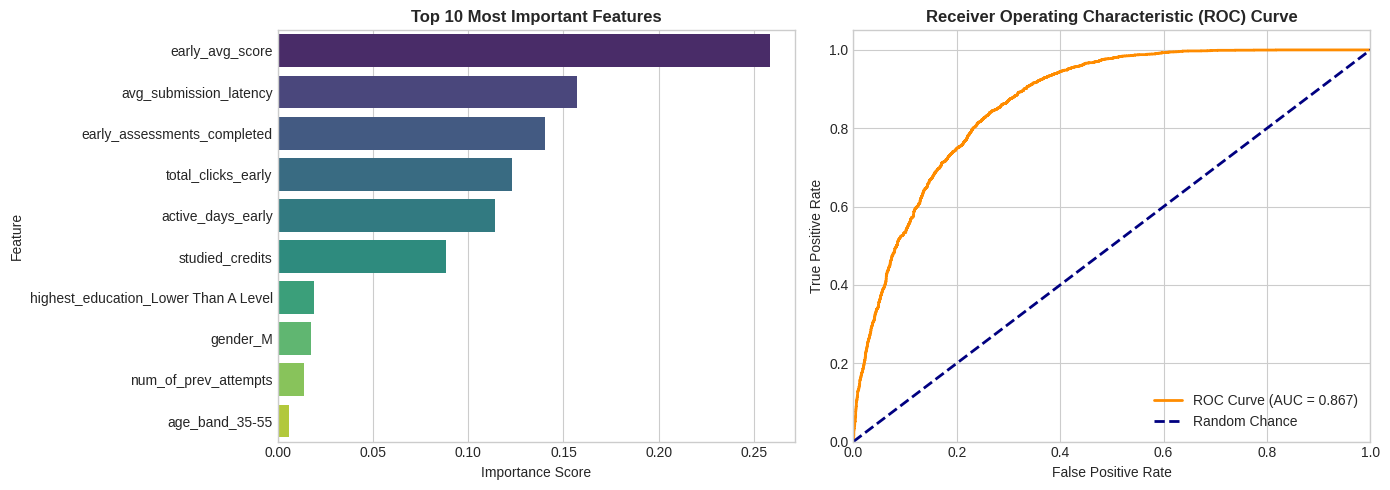

In [8]:
# ==========================================================
# CELL 8: Visualizing Feature Importances & ROC Curve
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(14, 5))

# 1. Plot Top 10 Feature Importances
plt.subplot(1, 2, 1)
importances = rf_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

sns.barplot(
    data=feature_imp_df,
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 10 Most Important Features', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# 2. Plot ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

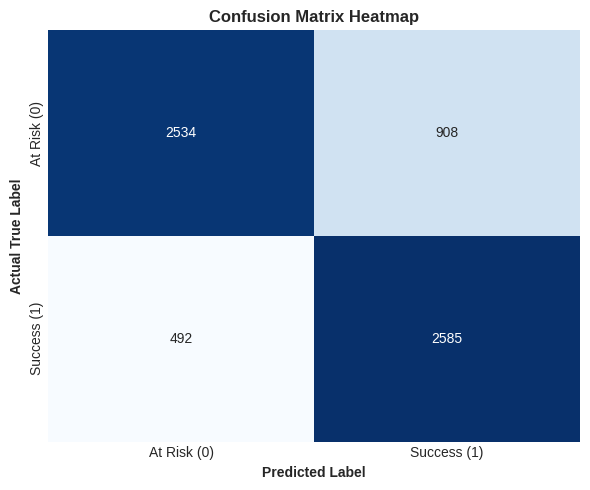

In [9]:
# ==========================================================
# CELL 9: Visualizing Confusion Matrix Heatmap
# ==========================================================
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['At Risk (0)', 'Success (1)'],
    yticklabels=['At Risk (0)', 'Success (1)']
)

plt.title('Confusion Matrix Heatmap', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('Actual True Label', fontweight='bold')

plt.tight_layout()
plt.show()